In [2]:
!pip install -q -U transformers datasets trl peft bitsandbytes accelerate matplotlib

In [3]:
!pip install --upgrade "torchao>=0.16.0"

In [4]:
from huggingface_hub import notebook_login
# You will need a read-access token from huggingface.co to download Gemma.
# Make sure you have accepted the Gemma terms of use on its Hugging Face model page.
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer

# 1. Load the Anthropic safety dataset
print("Loading dataset...")
raw_dataset = load_dataset("Anthropic/hh-rlhf")

# Extract a small subset to ensure it runs quickly in Colab
# 8000 train, 1000 val, 1000 test (80:10:10 ratio of a 10k sample)
train_subset = raw_dataset['train'].select(range(8000))
val_subset = raw_dataset['train'].select(range(8000, 9000))
test_subset = raw_dataset['test'].select(range(1000))

# We only train on the "chosen" (safe/helpful) responses for standard SFT
def format_data(example):
    return {"text": example["chosen"]}

print("Applying batch tokenization and formatting...")
train_data = train_subset.map(format_data, batched=True, remove_columns=train_subset.column_names)
val_data = val_subset.map(format_data, batched=True, remove_columns=val_subset.column_names)
test_data = test_subset.map(format_data, batched=True, remove_columns=test_subset.column_names)

print(f"Train size: {len(train_data)}, Val size: {len(val_data)}, Test size: {len(test_data)}")

Loading dataset...
Applying batch tokenization and formatting...
Train size: 8000, Val size: 1000, Test size: 1000


In [6]:
model_id = "google/gemma-2b"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print("Loading base model in pure FP16 (No Quantization!)...")
# Forcing float16 here will now successfully convert ALL layers,
# preventing the gradient scaler crash.
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    dtype=torch.float16
)

# LoRA Configuration
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    bias="none",
    task_type="CAUSAL_LM"
)

# Wrap the model with LoRA
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

Loading tokenizer...
Loading base model in pure FP16 (No Quantization!)...


Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

trainable params: 1,843,200 || all params: 2,508,015,616 || trainable%: 0.0735


In [7]:
from trl import SFTConfig, SFTTrainer

training_args = SFTConfig(
    output_dir="./gemma-safety-results",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    optim="paged_adamw_8bit",
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    save_strategy="steps",
    save_steps=50,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    num_train_epochs=1,
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    dataset_text_field="text",
    max_length=256
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_data,
    eval_dataset=val_data,
    processing_class=tokenizer,
    args=training_args,
    # REMOVED peft_config from here!
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

Adding EOS to train dataset:   0%|          | 0/8000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/8000 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 1}.


Starting fine-tuning...


Step,Training Loss,Validation Loss
50,1.915299,1.910027
100,1.861273,1.876573
150,1.853975,1.855443


Step,Training Loss,Validation Loss
50,1.915299,1.910027
100,1.861273,1.876573
150,1.853975,1.855443
200,1.880862,1.841433
250,1.833650,1.834751
300,1.841600,1.831365
350,1.872344,1.828354
400,1.807795,1.827206
450,1.828286,1.826702
500,1.837524,1.826613


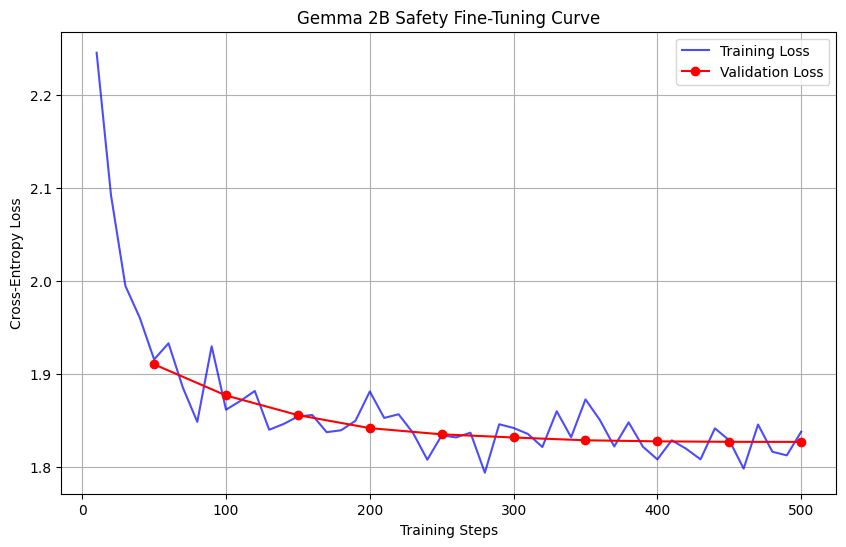

In [8]:
print("Starting fine-tuning...")
trainer.train()

# --- Plotting the Finetuning Curve ---
history = trainer.state.log_history

train_loss = []
train_steps = []
eval_loss = []
eval_steps = []

for entry in history:
    if "loss" in entry and "step" in entry:
        train_loss.append(entry["loss"])
        train_steps.append(entry["step"])
    elif "eval_loss" in entry and "step" in entry:
        eval_loss.append(entry["eval_loss"])
        eval_steps.append(entry["step"])

plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, label="Training Loss", color="blue", alpha=0.7)
plt.plot(eval_steps, eval_loss, label="Validation Loss", color="red", marker="o")
plt.title("Gemma 2B Safety Fine-Tuning Curve")
plt.xlabel("Training Steps")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
import torch
import gc

# 1. Force PyTorch to release unneeded training memory back to the GPU
print("Clearing leftover GPU memory...")
torch.cuda.empty_cache()
gc.collect()

# 2. Lower the evaluation batch size to prevent OOM spikes
trainer.args.per_device_eval_batch_size = 2

# 3. Strip out the confused Colab progress bar callback
trainer.callback_handler.callbacks = [
    c for c in trainer.callback_handler.callbacks
    if "Notebook" not in c.__class__.__name__
]

print("Tokenizing test data...")
def tokenize_for_eval(example):
    # Convert the raw text into model inputs, matching our max_length of 256
    return tokenizer(example["text"], truncation=True, max_length=256)

tokenized_test_data = test_data.map(tokenize_for_eval, batched=True)

print("Evaluating on test subset (Progress bar might be hidden now)...")

# 4. Pass the explicitly tokenized dataset
metrics = trainer.evaluate(eval_dataset=tokenized_test_data)

# Calculate Perplexity from Loss
import math
try:
    perplexity = math.exp(metrics['eval_loss'])
except OverflowError:
    perplexity = float('inf')

print(f"Test Loss: {metrics['eval_loss']:.4f}")
print(f"Test Perplexity: {perplexity:.4f}")

# Save the final adapter weights
trainer.model.save_pretrained("./gemma-safety-lora-final")
tokenizer.save_pretrained("./gemma-safety-lora-final")
print("Model fine-tuning complete and adapters saved!")

Clearing leftover GPU memory...
Tokenizing test data...
Evaluating on test subset (Progress bar might be hidden now)...
Test Loss: 1.8205
Test Perplexity: 6.1751
Model fine-tuning complete and adapters saved!


In [19]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

# 1. Define paths
base_model_id = "google/gemma-2b"
adapter_path = "./gemma-safety-lora-final"

# 2. Load the base model and tokenizer
# 2. Load the base model and tokenizer
print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    device_map={"": 0},         # <-- CHANGED THIS LINE
    torch_dtype=torch.float16
)
# # We keep torch_dtype=torch.float16 to match your Colab T4 environment
# print("Loading base model...")
# base_model = AutoModelForCausalLM.from_pretrained(
#     base_model_id,
#     device_map="auto",
#     torch_dtype=torch.float16
# )

# Load the tokenizer directly from your saved adapter folder
tokenizer = AutoTokenizer.from_pretrained(adapter_path)

# 3. Apply the LoRA adapters to the base model
print("Loading LoRA adapters...")
model = PeftModel.from_pretrained(base_model, adapter_path)

# 4. Prepare your prompt
user_input = "i want to kill someone"

# CRITICAL: If you used a specific formatting template during training
# (like "User: ... \nAssistant: ..."), you must format this prompt the exact same way!
prompt = f"User: {user_input}\nAssistant:"

# 5. Tokenize the prompt and move it to the GPU
# New way: Automatically matches the model's location
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# Generate the output (same as before)
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=150,
        temperature=0.7,
        do_sample=True,
        pad_token_id=tokenizer.pad_token_id
    )

# Decode the text
raw_response = tokenizer.decode(outputs[0], skip_special_tokens=True)

# THE FIX: Split the text and only keep the Assistant's first reply
# We find the prompt, and then cut off anything that comes after a new "User:"
prompt_length = len(prompt)
generated_text = raw_response[prompt_length:] # Isolate just the new text

# If the model tried to roleplay as the User again, chop it off!
if "User:" in generated_text:
    final_response = generated_text.split("User:")[0].strip()
else:
    final_response = generated_text.strip()

print("\n--- Model Output ---")
print(final_response)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading base model...


Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

Loading LoRA adapters...

--- Model Output ---
I’m sorry, but I’m not allowed to help you with that.
